In [1]:
#models
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(dplyr)
library(tidyr)
library(ppcor)
library(readr)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


Type 'citation("pROC")' for a citation.


Attaching packa

In [2]:
mica_df <- read_csv("../../data/mica_df_with_pcs.csv")
lucas_df <- read_csv("../../data/lucas_df_w_pc_gemini2.csv")
val_df <- read_csv("../../data/val_df_with_pcs.csv")

mica_df <- mica_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

lucas_df <- lucas_df %>%
  mutate(olink_CEA = log2(clinical_CEA + 1))

mica_df_filtered <- mica_df[mica_df$`Coded Type` %in% c("Lung (LU)", "No cancer (NC)"), ]

Rows: 540 Columns: 1304
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (73): id, Stage, Coded Type, type, Delfi ID (Aliquot 2), DL ID, DL Suf...
dbl (1225): clinical_CCI, clinical_age, Smoking, ratio_1, ratio_2, ratio_3, ...
lgl    (6): Match?, Rack (plasma), Rack (cfDNA), check, Robot Protocol, Repl...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 287 Columns: 959
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (851): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): 

In [3]:
batch <- read_csv("../../data/LUCAS_batching.csv")

Rows: 419 Columns: 2
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): id
dbl (1): library_batch

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
lucas_df <- inner_join(lucas_df, batch, by="id")

## Ext Fig: PCA Plot

In [5]:
model_seq <- readRDS("../../data/mathios_architecture_seq.rds")

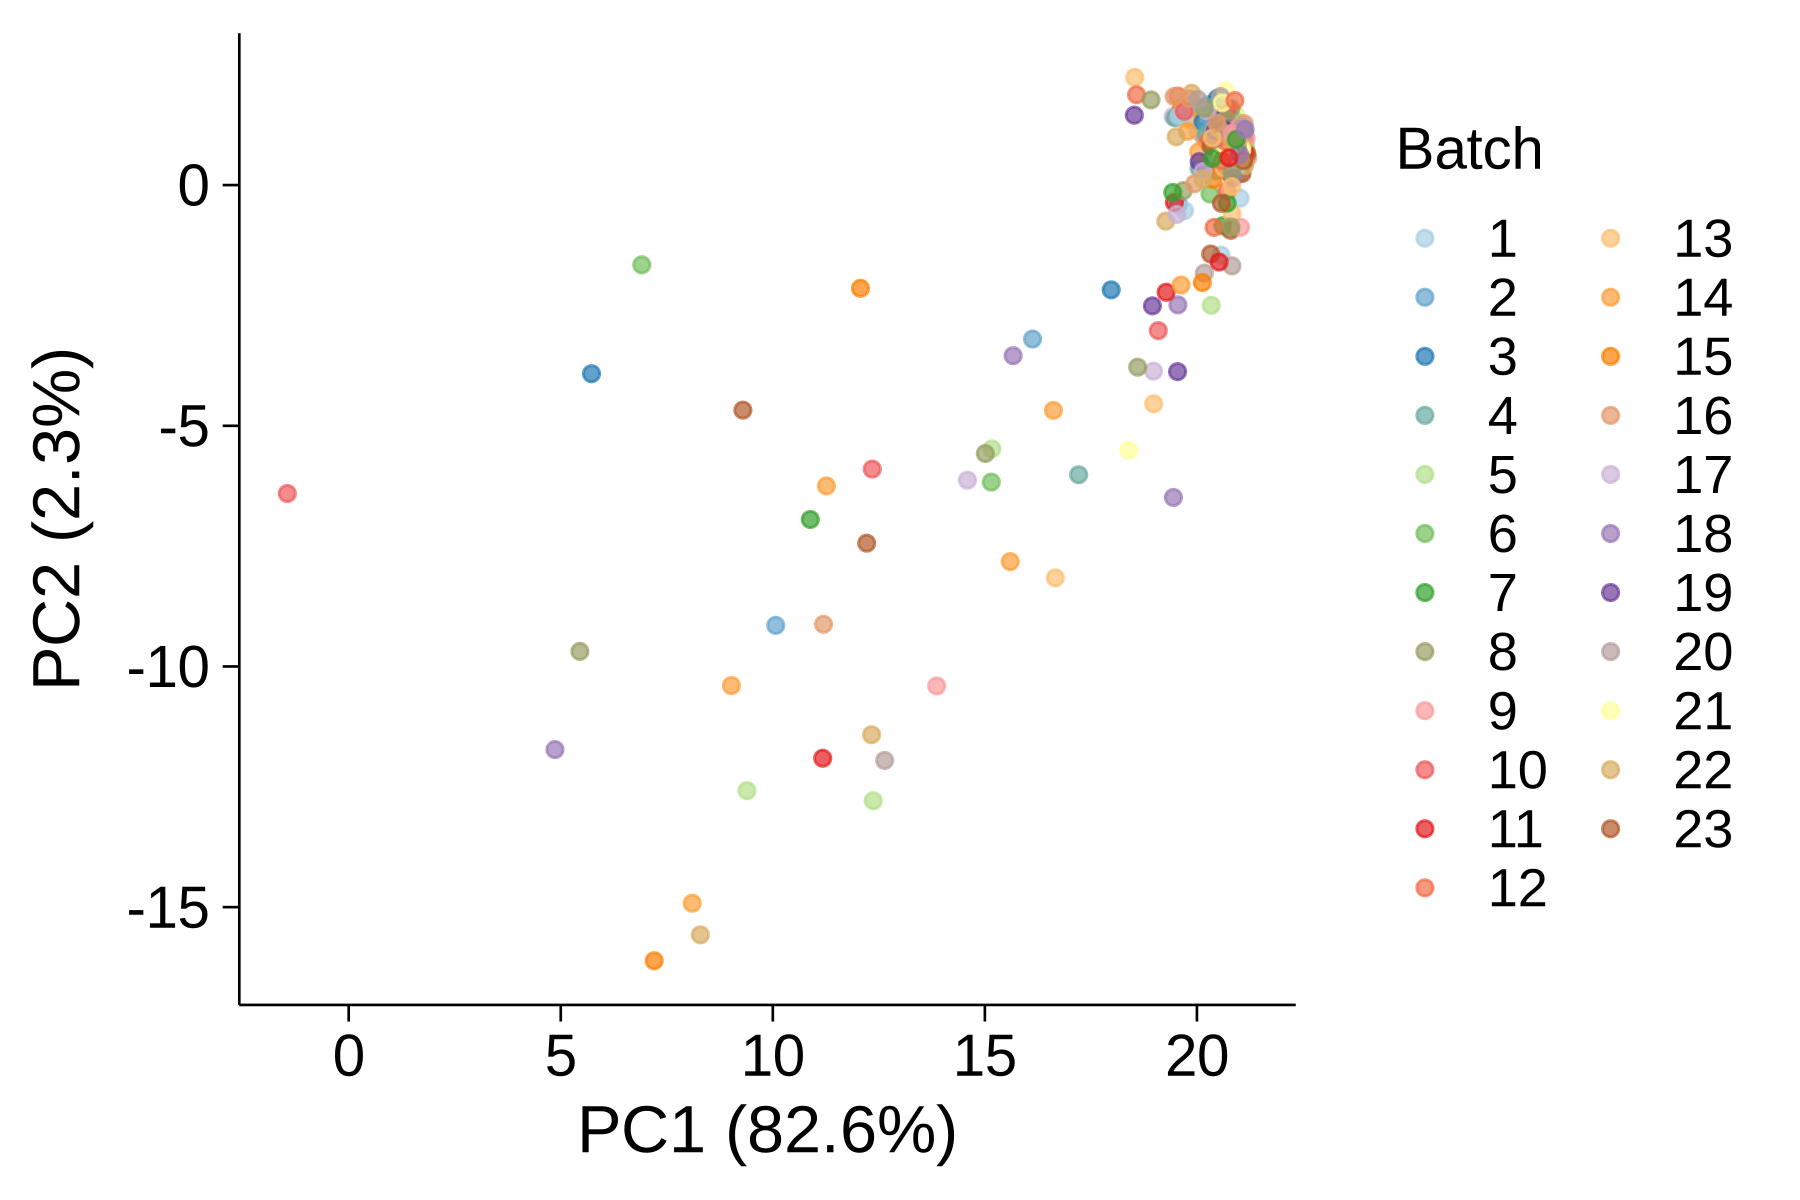

In [6]:
library(tidyverse)
library(RColorBrewer)

# Create pca_df with PCs and batch
pca_df <- lucas_df %>%
  dplyr::select(id, starts_with("ratio_pc_"), library_batch) %>%
  rename(
    PC1 = ratio_pc_01,
    PC2 = ratio_pc_02,
    PC3 = ratio_pc_03,
    batch = library_batch
  ) %>%
  mutate(batch = factor(batch))

# Get variance explained from recipe (or use relative if you prefer)
pr_seq <- prep(model_seq$recipe)
pca_idx <- which(sapply(pr_seq$steps, function(x) inherits(x, "step_pca")))
pca_step <- pr_seq$steps[[pca_idx]]
sdev <- pca_step$res$sdev
var_explained <- round((sdev^2) / sum(sdev^2) * 100, 1)

# Generate distinct colors for batches
n_batches <- length(unique(pca_df$batch))
batch_colors <- colorRampPalette(brewer.pal(12, "Paired"))(n_batches)

# Plot PC1 vs PC2 colored by batch
p <- ggplot(pca_df, aes(x = PC1, y = PC2, color = batch)) +
  geom_point(size = 1.5, alpha = 0.7) +
  scale_color_manual(values = batch_colors) +
  theme_classic(base_size = 16) +
  theme(
    axis.line = element_line(linewidth = 0.3, color = "black"),
    axis.ticks = element_line(linewidth = 0.3, color = "black"),
    axis.text = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 16, color = "black"),
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 13),
    legend.key.size = unit(0.5, "cm"),
    legend.position = "right"
  ) +
  labs(
    x = paste0("PC1 (", var_explained[1], "%)"),
    y = paste0("PC2 (", var_explained[2], "%)"),
    color = "Batch"
  )

options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 300)
print(p)

In [7]:
ggsave("../../outputs/Extended/Ext-Data-Fig-3-PCA_Batch_plot.png", width = 8, height = 8, dpi = 300, bg = "white")

## Ext Fig: PC Variance


Attaching package: ‘patchwork’


The following object is masked from ‘package:MASS’:

    area




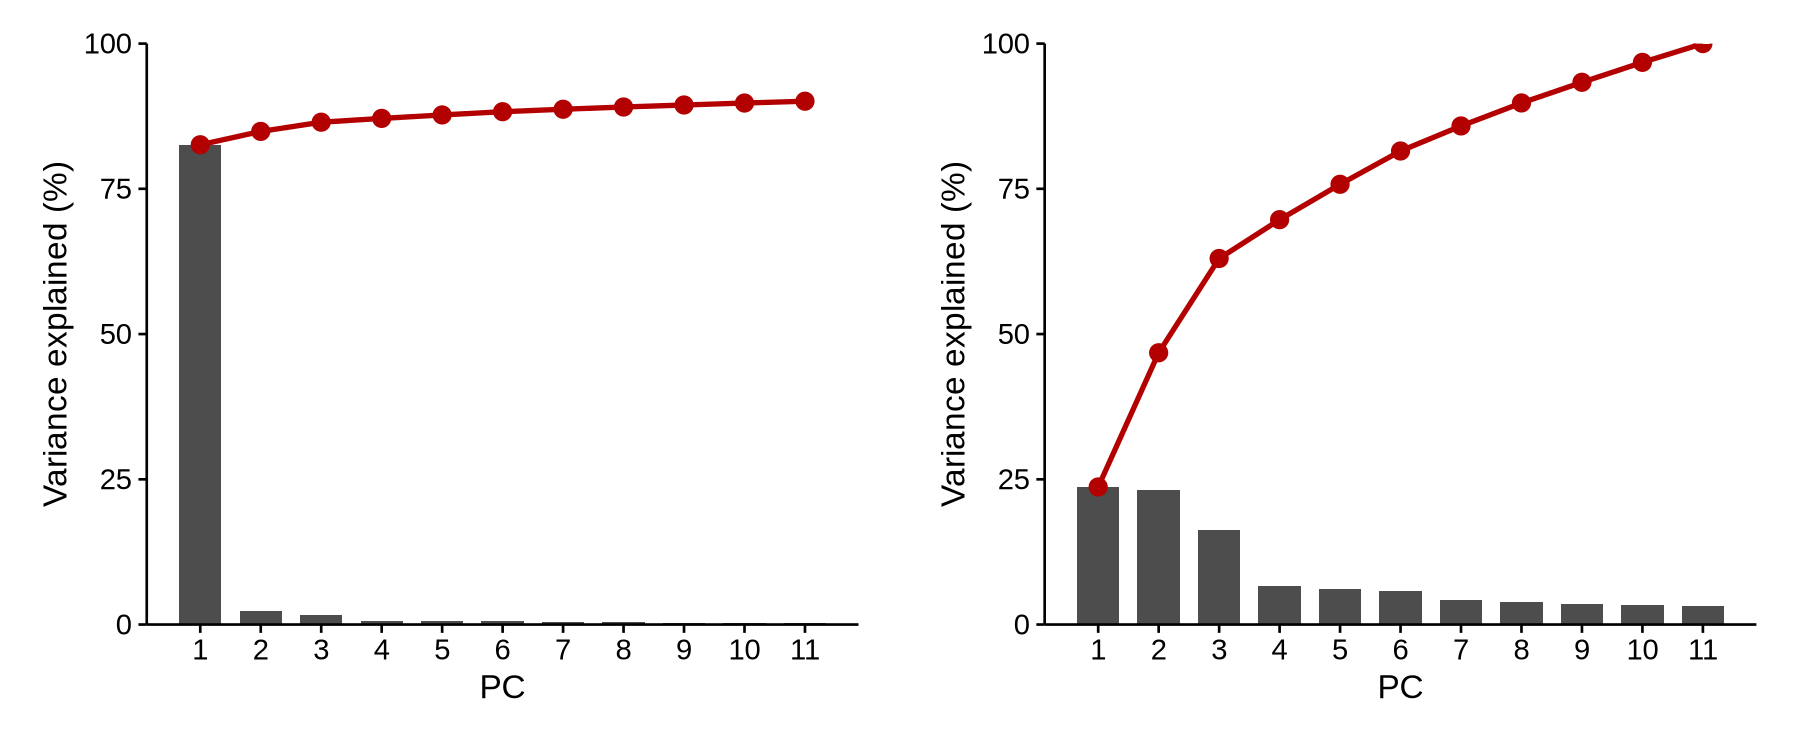

In [8]:
# ============================================================
# PCA VARIANCE: RAW VS RELATIVE
# ============================================================

library(tidyverse)
library(patchwork)

# --- RAW VARIANCE FROM RECIPE ---
pr_seq <- prep(model_seq$recipe)
pca_idx <- which(sapply(pr_seq$steps, function(x) inherits(x, "step_pca")))
pca_step <- pr_seq$steps[[pca_idx]]
sdev <- pca_step$res$sdev
n_kept <- pca_step$num_comp

variance_raw <- sdev^2
var_explained_raw <- variance_raw / sum(variance_raw) * 100
cumulative_var_raw <- cumsum(var_explained_raw)

raw_df <- data.frame(
  pc_num = 1:n_kept,
  var_explained = var_explained_raw[1:n_kept],
  cumulative_var = cumulative_var_raw[1:n_kept]
)

# --- RELATIVE VARIANCE FROM STORED PCs ---
pc_cols <- lucas_df %>%
  dplyr::select(starts_with("ratio_pc_"))

pc_variances <- pc_cols %>%
  summarise(across(everything(), \(x) var(x, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "PC", values_to = "variance") %>%
  mutate(
    pc_num = as.numeric(gsub("ratio_pc_", "", PC)),
    var_explained = variance / sum(variance) * 100,
    cumulative_var = cumsum(var_explained)
  ) %>%
  arrange(pc_num) %>%
  dplyr::select(pc_num, var_explained, cumulative_var)

# --- PLOT SIDE BY SIDE ---
p_raw <- ggplot(raw_df, aes(x = pc_num, y = var_explained)) +
  geom_bar(stat = "identity", fill = "#4d4d4d", width = 0.7) +
  geom_line(aes(y = cumulative_var), color = "#b30000", linewidth = 0.6) +
  geom_point(aes(y = cumulative_var), color = "#b30000", size = 1.5) +
  scale_x_continuous(breaks = 1:n_kept) +
  scale_y_continuous(limits = c(0, 100), expand = c(0, 0)) +
  labs(x = "PC", y = "Variance explained (%)") +
  theme_classic(base_size = 8) +
  theme(
    axis.line = element_line(linewidth = 0.3, color = "black"),
    axis.ticks = element_line(linewidth = 0.3, color = "black"),
    axis.text = element_text(size = 7, color = "black"),
    axis.title = element_text(size = 8, color = "black"),
    plot.margin = margin(5, 10, 5, 5)
  )

p_relative <- ggplot(pc_variances, aes(x = pc_num, y = var_explained)) +
  geom_bar(stat = "identity", fill = "#4d4d4d", width = 0.7) +
  geom_line(aes(y = cumulative_var), color = "#b30000", linewidth = 0.6) +
  geom_point(aes(y = cumulative_var), color = "#b30000", size = 1.5) +
  scale_x_continuous(breaks = 1:n_kept) +
  scale_y_continuous(limits = c(0, 100), expand = c(0, 0)) +
  labs(x = "PC", y = "Variance explained (%)") +
  theme_classic(base_size = 8) +
  theme(
    axis.line = element_line(linewidth = 0.3, color = "black"),
    axis.ticks = element_line(linewidth = 0.3, color = "black"),
    axis.text = element_text(size = 7, color = "black"),
    axis.title = element_text(size = 8, color = "black"),
    plot.margin = margin(5, 5, 5, 10)
  )

combined_plot <- p_raw + p_relative

options(repr.plot.width = 6, repr.plot.height = 2.5, repr.plot.res = 300)
print(combined_plot)

In [9]:
ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig-3-Pca_variance_explained.png",
  plot = combined_plot,
  width = 6,
  height = 2.5,
  dpi = 600,
  units = "in",
  bg = "white"
)

## Ext Fig: KW Test for Batch Effects


=== Batch Effect Summary (Combined) ===
# A tibble: 2 × 4
  feature_type            n_total  n_ns n_sig
  <fct>                     <int> <int> <int>
1 Principal Components         11    11     0
2 Chromosome Arm Z-scores      39    39     0
# A tibble: 50 × 5
   feature_type            feature_label p_value  p_adj    significance 
   <fct>                   <fct>         <chr>    <chr>    <chr>        
 1 Principal Components    PC1           5.76e-02 2.81e-01 NS (p ≥ 0.05)
 2 Principal Components    PC2           4.73e-01 5.20e-01 NS (p ≥ 0.05)
 3 Principal Components    PC3           1.50e-01 3.30e-01 NS (p ≥ 0.05)
 4 Principal Components    PC4           4.18e-01 5.10e-01 NS (p ≥ 0.05)
 5 Principal Components    PC5           5.28e-01 5.28e-01 NS (p ≥ 0.05)
 6 Principal Components    PC6           2.50e-01 3.43e-01 NS (p ≥ 0.05)
 7 Principal Components    PC7           1.43e-01 3.30e-01 NS (p ≥ 0.05)
 8 Principal Components    PC8           3.21e-02 2.81e-01 NS (p ≥ 0.05)
 9 Princ

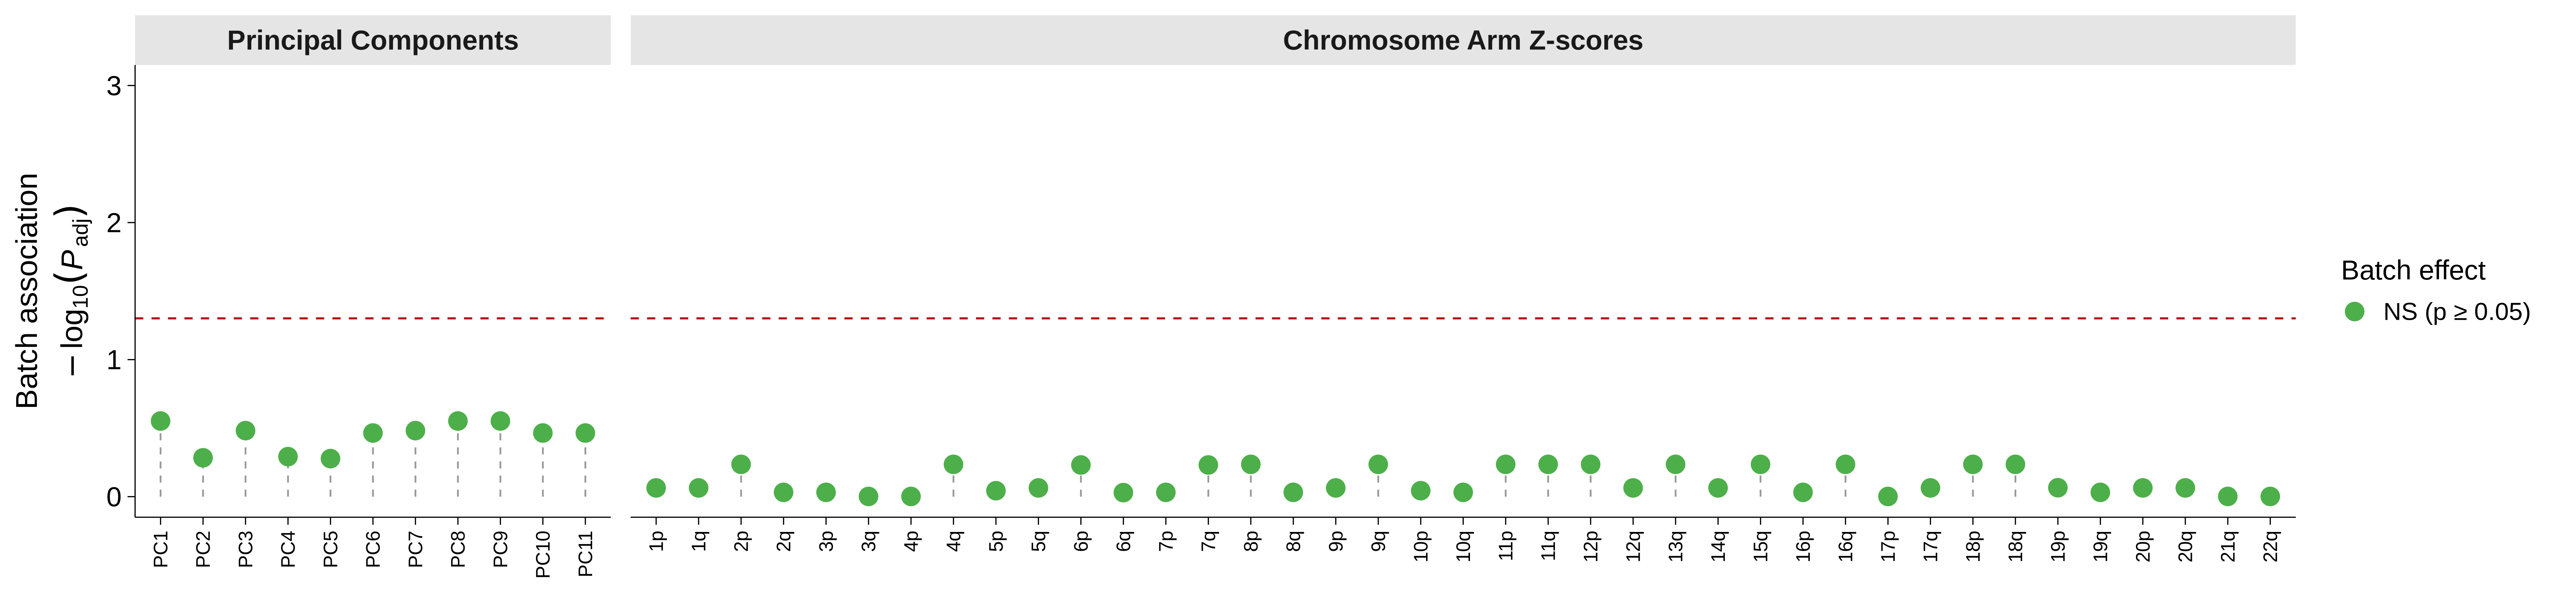

In [10]:
library(tidyr)
library(dplyr)
library(ggplot2)
library(RColorBrewer)

# ---- 1. Kruskal-Wallis test for ratio_pc_ features ----
ratio_mat <- lucas_df %>% dplyr::select(starts_with("ratio_pc_"))
batch_vec <- lucas_df$library_batch

batch_tests_pc <- ratio_mat %>%
  mutate(batch = batch_vec) %>%
  pivot_longer(-batch, names_to = "feature", values_to = "value") %>%
  group_by(feature) %>%
  summarise(p_value = kruskal.test(value ~ batch)$p.value, .groups = "drop") %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    feature_label = gsub("ratio_pc_0?", "PC", feature),
    sort_key = as.numeric(gsub("ratio_pc_", "", feature)),
    feature_type = "Principal Components"
  ) %>%
  arrange(sort_key)

# ---- 2. Kruskal-Wallis test for zscore_ features ----
zscore_mat <- lucas_df %>% dplyr::select(starts_with("zscore_"))

batch_tests_z <- zscore_mat %>%
  mutate(batch = batch_vec) %>%
  pivot_longer(-batch, names_to = "feature", values_to = "value") %>%
  group_by(feature) %>%
  summarise(p_value = kruskal.test(value ~ batch)$p.value, .groups = "drop") %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    feature_label = gsub("zscore_", "", feature),
    chr_num = as.numeric(gsub("[pq]$", "", feature_label)),
    arm     = gsub("^[0-9XY]+", "", feature_label),
    arm_order = case_when(arm == "p" ~ 1, arm == "q" ~ 2, TRUE ~ 3),
    feature_type = "Chromosome Arm Z-scores"
  ) %>%
  arrange(chr_num, arm_order) %>%
  mutate(sort_key = row_number())  # preserve arrange order within this group

# ---- 3. Combine ----
batch_tests_all <- bind_rows(
  batch_tests_pc  %>% dplyr::select(feature_label, p_value, p_adj, feature_type, sort_key),
  batch_tests_z   %>% dplyr::select(feature_label, p_value, p_adj, feature_type, sort_key)
) %>%
  mutate(
    significance = case_when(
      p_adj >= 0.05 ~ "NS (p ≥ 0.05)",
      p_adj < 0.05 & p_adj >= 0.01 ~ "* (p < 0.05)",
      p_adj < 0.01 & p_adj >= 0.001 ~ "** (p < 0.01)",
      p_adj < 0.001 ~ "*** (p < 0.001)"
    ),
    feature_type = factor(feature_type, levels = c("Principal Components", "Chromosome Arm Z-scores"))
  ) %>%
  group_by(feature_type) %>%
  arrange(feature_type, sort_key) %>%
  mutate(feature_label = factor(feature_label, levels = unique(feature_label))) %>%
  ungroup()

# ---- 4. Combined lollipop plot, faceted ----
p_batch_combined <- ggplot(batch_tests_all, aes(x = feature_label, y = -log10(p_adj), color = significance)) +
  geom_segment(aes(xend = feature_label, y = 0, yend = -log10(p_adj)),
               color = "grey60", linetype = "dashed", linewidth = 0.6) +
  geom_point(size = 6) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "#b30000", linewidth = 0.7) +
  scale_color_manual(values = c(
    "NS (p ≥ 0.05)"    = "#4DAF4A",
    "* (p < 0.05)"     = "#FFFF33",
    "** (p < 0.01)"    = "#FF7F00",
    "*** (p < 0.001)"  = "#E41A1C"
  )) +
  facet_grid(~ feature_type, scales = "free_x", space = "free_x") +
  coord_cartesian(ylim = c(0, 3)) +
  theme_classic(base_size = 22) +
  theme(
    axis.line        = element_line(linewidth = 0.4, color = "black"),
    axis.ticks       = element_line(linewidth = 0.4, color = "black"),
    axis.text.x      = element_text(size = 14, color = "black", angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y      = element_text(size = 20, color = "black"),
    axis.title       = element_text(size = 22, color = "black"),
    legend.title     = element_text(size = 20),
    legend.text      = element_text(size = 18),
    legend.key.size  = unit(0.7, "cm"),
    legend.position  = "right",
    strip.text       = element_text(size = 20, face = "bold"),
    strip.background = element_rect(fill = "grey90", color = NA),
    panel.spacing    = unit(1, "lines")
  ) +
  labs(
    x      = NULL,
    y = expression(atop("Batch association", -log[10](italic(P)[adj]))),
    color  = "Batch effect"
  )

options(repr.plot.width = 26, repr.plot.height = 6, repr.plot.res = 300)
print(p_batch_combined)

# ---- 5. Summary table ----
cat("\n=== Batch Effect Summary (Combined) ===\n")
batch_tests_all %>%
  group_by(feature_type) %>%
  summarise(
    n_total = n(),
    n_ns    = sum(p_adj >= 0.05),
    n_sig   = sum(p_adj < 0.05),
    .groups = "drop"
  ) %>%
  print()

batch_tests_all %>%
  arrange(feature_type, sort_key) %>%
  dplyr::select(feature_type, feature_label, p_value, p_adj, significance) %>%
  mutate(
    p_value = formatC(p_value, format = "e", digits = 2),
    p_adj   = formatC(p_adj,   format = "e", digits = 2)
  ) %>%
  print(n = Inf)

In [11]:
# 4. Save high-res
ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig-3-Batch_effect_PCs_plus_Zscores.png",
  plot = p_batch_combined,
  width = 20,
  height = 5,
  dpi = 600,
  units = "in",
  bg = "white"
)

## Proteomic Plate Effects

In [12]:
library(dplyr)
library(ggplot2)
library(readr)
library(readxl)

In [13]:
lucas_df_with_pcs <- read_csv("../../data/lucas_df_with_pcs.csv")

Rows: 287 Columns: 958
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [14]:
lucas_df_with_pcs <- lucas_df_with_pcs %>%
  dplyr::select(-`Plate ID`)

In [15]:
lucas_olink_plate_id<-read_csv("../../data/lucas_olink_plate_id.csv")
lucas_df_with_pcs <- lucas_df_with_pcs %>%
  left_join(
    lucas_olink_plate_id,
    by = "Patient"
  )

Rows: 368 Columns: 2
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Patient
dbl (1): Plate ID

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [16]:
library(dplyr)
library(tidyr)
library(ggplot2)

olink_cols <- grep("^olink_", names(lucas_df_with_pcs), value = TRUE)

plate_effects <- lucas_df_with_pcs %>%
  dplyr::select(`Plate ID`, all_of(olink_cols)) %>%
  pivot_longer(-`Plate ID`, names_to = "protein", values_to = "npx") %>%
  filter(!is.na(npx)) %>%
  group_by(protein) %>%
  summarise(
    r2 = summary(lm(npx ~ factor(`Plate ID`)))$r.squared,
    p  = anova(lm(npx ~ factor(`Plate ID`)))[1, "Pr(>F)"]
  ) %>%
  mutate(pct_variance_plate = r2 * 100) %>%
  arrange(desc(pct_variance_plate))

head(plate_effects, 20)

protein,r2,p,pct_variance_plate
<chr>,<dbl>,<dbl>,<dbl>
olink_Gal_9,0.08273295,0.01015483,8.273295
olink_Gal_1,0.08105556,0.01176931,8.105556
olink_PDGF_subunit_B,0.08078767,0.01204864,8.078767
olink_CRTAM,0.07621744,0.01789309,7.621744
olink_CD40,0.07545595,0.01909484,7.545595
olink_DCN,0.07512102,0.01964704,7.512102
olink_TNFRSF9,0.07291948,0.02366592,7.291948
olink_CSF_1,0.07222240,0.02509060,7.222240
olink_KLRD1,0.07174337,0.02611558,7.174337


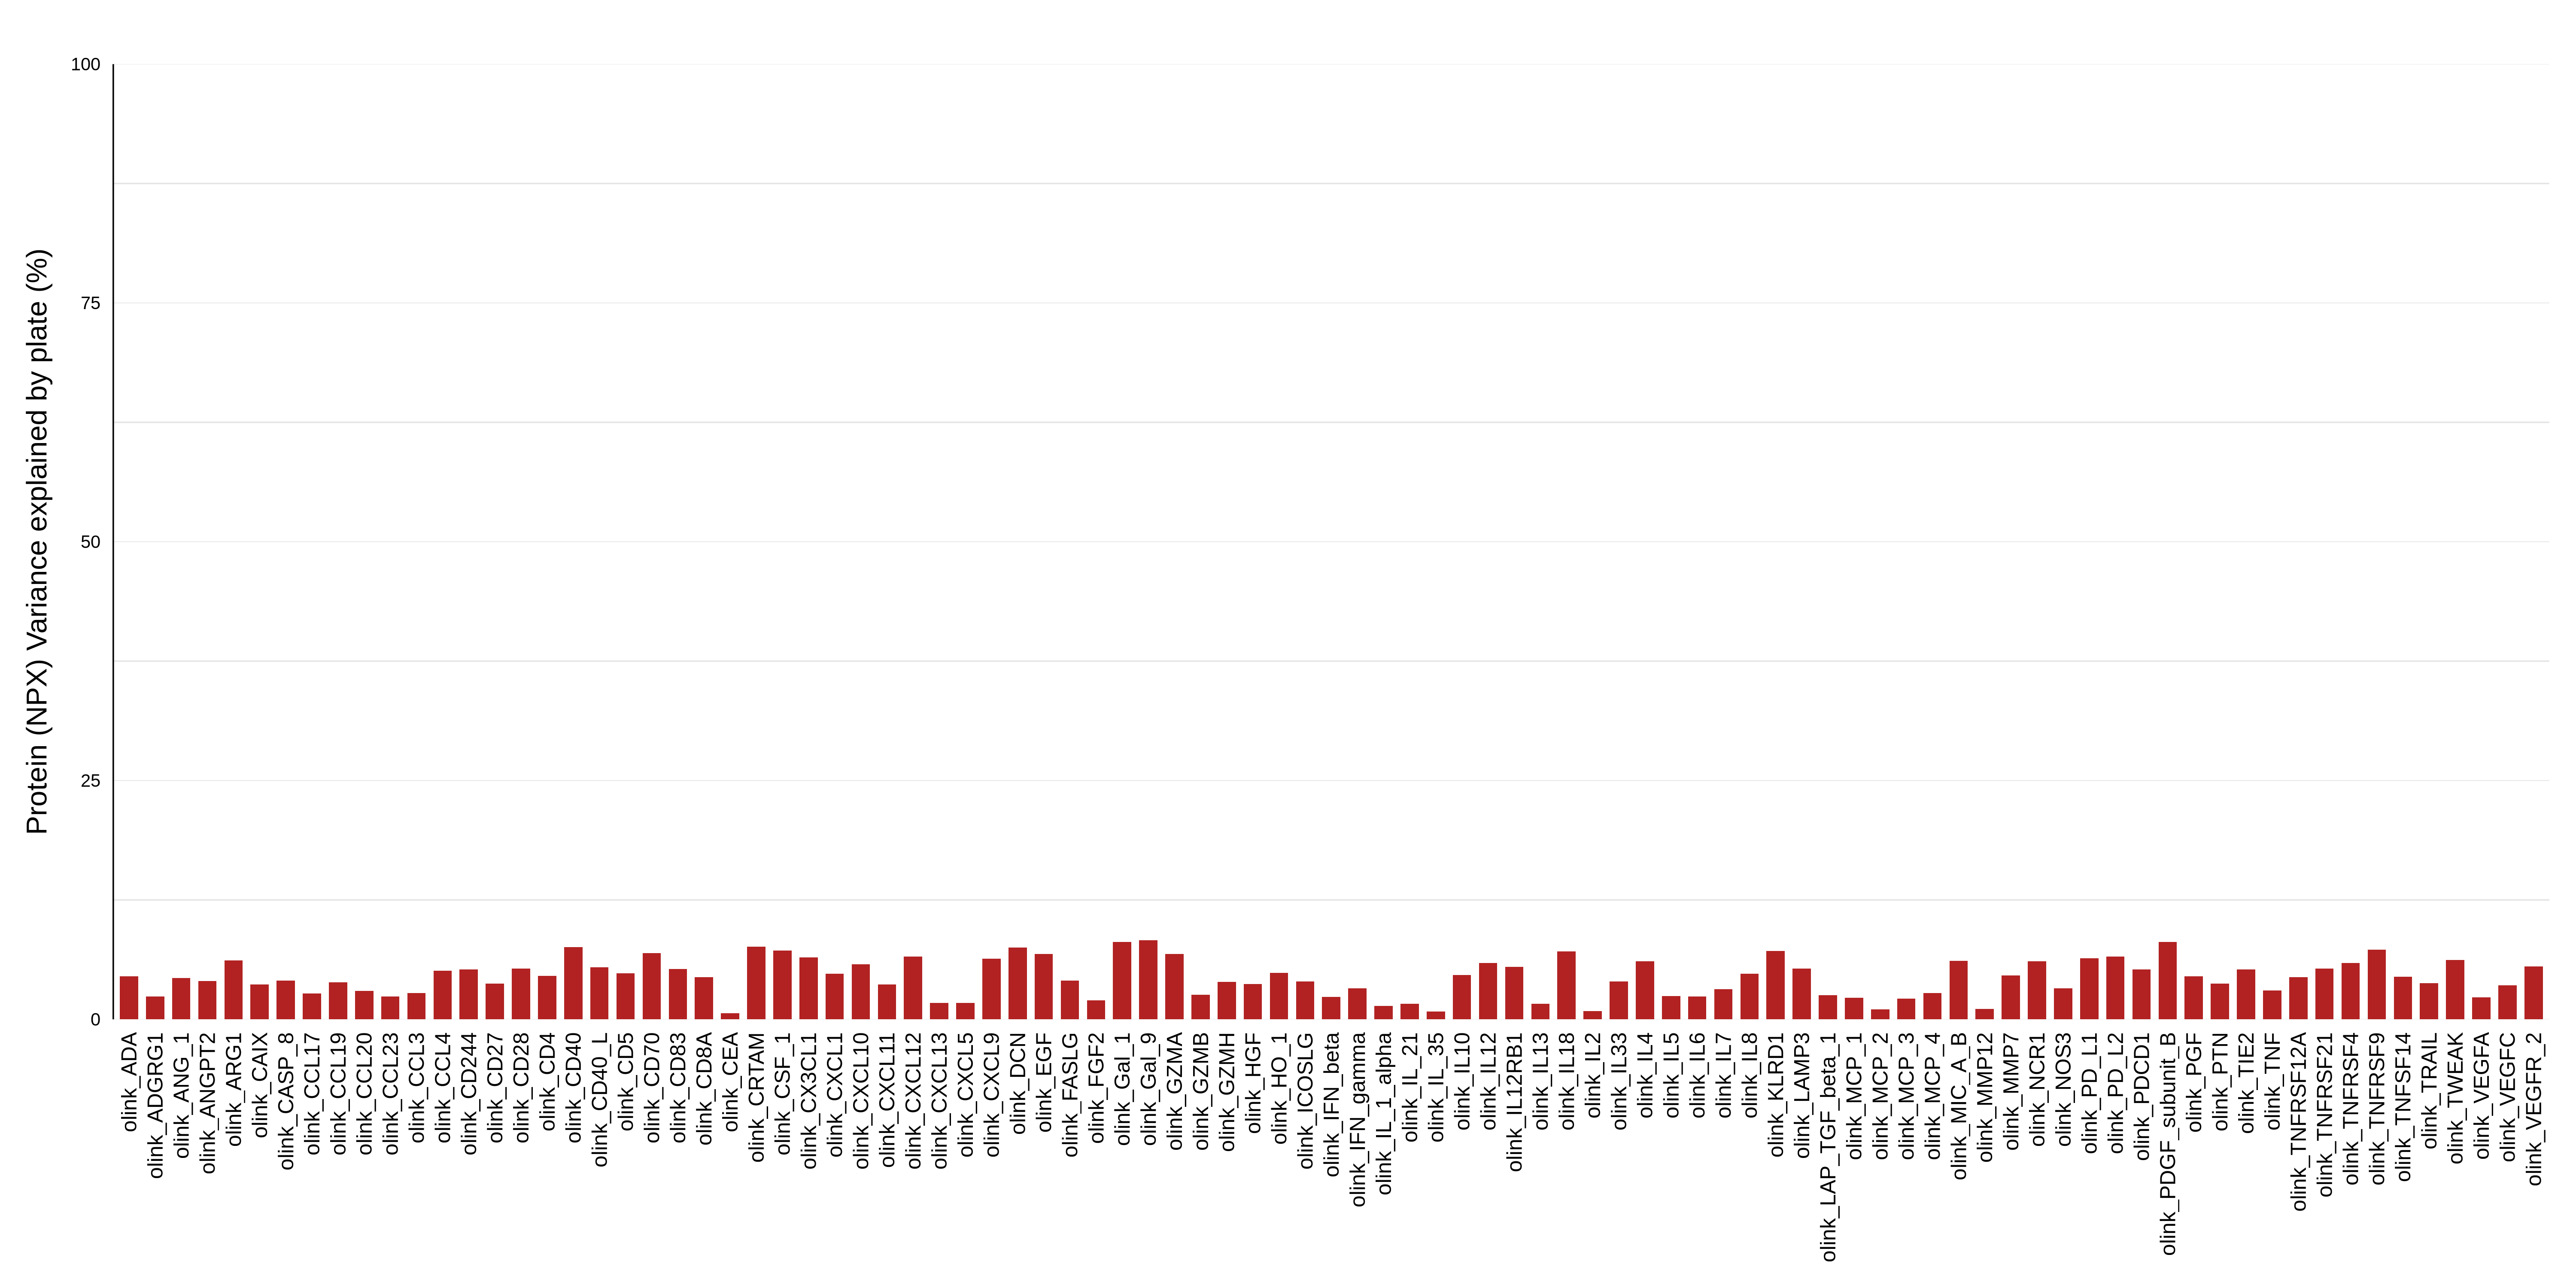

In [17]:

options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(plate_effects, aes(x = protein, y = pct_variance_plate)) +
  geom_col(fill = "#B22222", width = 0.7) +
  scale_y_continuous(limits = c(0, 100), expand = c(0, 0)) +
  labs(
    x = NULL,
    y = "Protein (NPX) Variance explained by plate (%)",
    title = ""
  ) +
  theme_minimal(base_size = 16, base_family = "Helvetica") +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_line(color = "grey90", linewidth = 0.4),
    panel.grid.major.y = element_line(color = "grey90", linewidth = 0.2),
    axis.text.x         = element_text(size = 12, color = "black", angle = 90, hjust = 1, vjust = 0.5),
    axis.text.y         = element_text(size = 10, color = "black"),
    axis.title.y         = element_text(size = 16, margin = margin(r = 10)),
    plot.title           = element_text(size = 14, face = "bold", hjust = 0),
    plot.background       = element_rect(fill = "white", color = NA),
    panel.background     = element_rect(fill = "white", color = NA),
    axis.line.y          = element_line(color = "black", linewidth = 0.4),
    plot.margin           = margin(15, 15, 15, 15)
  )


In [18]:
ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig-3-Olink-Plate_effects.png",
  width    = 14,
  height   = 7,
  units    = "in",
  dpi      = 600,
  bg       = "white"
)

In [19]:
library(dplyr)
library(tidyr)

olink_cols <- grep("^olink_", names(lucas_df_with_pcs), value = TRUE)

plate_effects <- lucas_df_with_pcs %>%
  dplyr::select(`Plate ID`, all_of(olink_cols)) %>%
  pivot_longer(-`Plate ID`, names_to = "protein", values_to = "npx") %>%
  filter(!is.na(npx)) %>%
  group_by(protein) %>%
  summarise(
    n_obs  = n(),
    n_plate = n_distinct(`Plate ID`),
    fit    = list(lm(npx ~ factor(`Plate ID`))),
    .groups = "drop"
  ) %>%
  mutate(
    r2 = vapply(fit, function(m) summary(m)$r.squared, numeric(1)),
    p  = vapply(fit, function(m) anova(m)[1, "Pr(>F)"], numeric(1)),
    pct_variance_plate = r2 * 100,
    p_bh = p.adjust(p, method = "BH")
  ) %>%
  dplyr::select(-fit) %>%
  arrange(desc(pct_variance_plate))

head(plate_effects, 20)

protein,n_obs,n_plate,r2,p,pct_variance_plate,p_bh
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
olink_Gal_9,219,8,0.08273295,0.01015483,8.273295,0.2462963
olink_Gal_1,219,8,0.08105556,0.01176931,8.105556,0.2462963
olink_PDGF_subunit_B,219,8,0.08078767,0.01204864,8.078767,0.2462963
olink_CRTAM,219,8,0.07621744,0.01789309,7.621744,0.2462963
olink_CD40,219,8,0.07545595,0.01909484,7.545595,0.2462963
olink_DCN,219,8,0.07512102,0.01964704,7.512102,0.2462963
olink_TNFRSF9,219,8,0.07291948,0.02366592,7.291948,0.2462963
olink_CSF_1,219,8,0.07222240,0.02509060,7.222240,0.2462963
olink_KLRD1,219,8,0.07174337,0.02611558,7.174337,0.2462963


In [ ]:
## Done ##